In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [3]:
df = pd.read_csv('data.csv')
print("Shape:", df.shape)
df.head()

Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,"342,000.00",3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,"420,000.00",3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,"550,000.00",4.00,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [5]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,"4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00","4,600.00"
mean,"551,962.99",3.40,2.16,"2,139.35","14,852.52",1.51,0.01,0.24,3.45,"1,827.27",312.08,"1,970.79",808.61
std,"563,834.70",0.91,0.78,963.21,"35,884.44",0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,"1,900.00",0.00
25%,"322,875.00",3.00,1.75,"1,460.00","5,000.75",1.00,0.00,0.00,3.00,"1,190.00",0.00,"1,951.00",0.00
50%,"460,943.46",3.00,2.25,"1,980.00","7,683.00",1.50,0.00,0.00,3.00,"1,590.00",0.00,"1,976.00",0.00
75%,"654,962.50",4.00,2.50,"2,620.00","11,001.25",2.00,0.00,0.00,4.00,"2,300.00",610.00,"1,997.00","1,999.00"
max,"26,590,000.00",9.00,8.00,"13,540.00","1,074,218.00",3.50,1.00,4.00,5.00,"9,410.00","4,820.00","2,014.00","2,014.00"


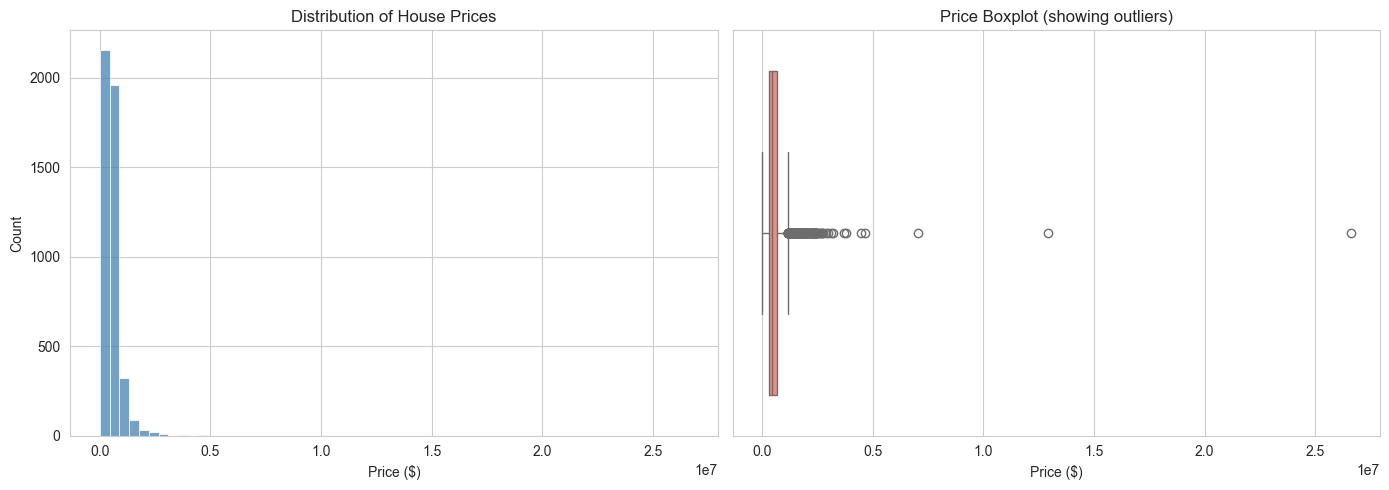

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['price'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of House Prices')
axes[0].set_xlabel('Price ($)')

sns.boxplot(x=df['price'], ax=axes[1], color='salmon')
axes[1].set_title('Price Boxplot (showing outliers)')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

In [7]:
print("Houses with price == 0:", (df['price'] == 0).sum())
print("Houses with price > $10,000,000:", (df['price'] > 10_000_000).sum())
df.sort_values('price', ascending=False)[['price','bedrooms','bathrooms','sqft_living','city']].head(5)

Houses with price == 0: 49
Houses with price > $10,000,000: 2


,price,bedrooms,bathrooms,sqft_living,city
4350,"26,590,000.00",3.00,2.00,1180,Kent
4346,"12,899,000.00",3.00,2.50,2190,Seattle
2286,"7,062,500.00",5.00,4.50,10040,Bellevue
2654,"4,668,000.00",5.00,6.75,9640,Mercer Island
2761,"4,489,000.00",4.00,3.00,6430,Bellevue


C:\Users\monis\AppData\Local\Temp\ipykernel_25356\4180895107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')


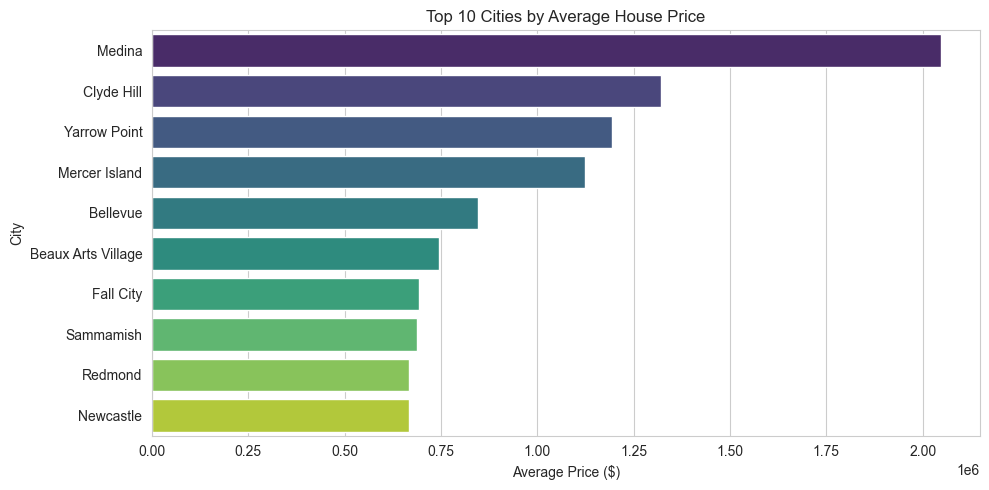

In [8]:
plt.figure(figsize=(10, 5))
top_cities = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 10 Cities by Average House Price')
plt.xlabel('Average Price ($)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

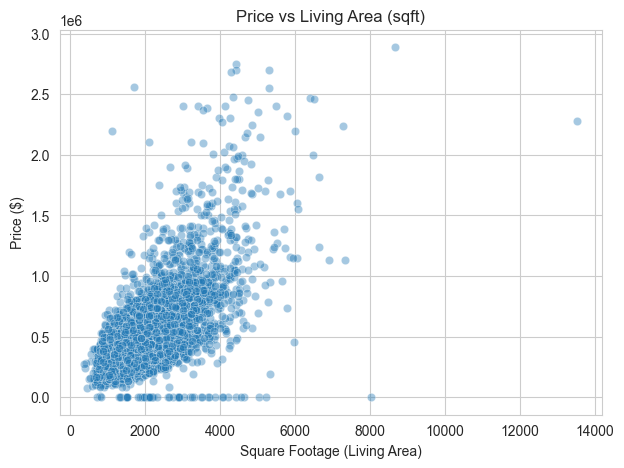

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df[df['price'] < 3_000_000], x='sqft_living', y='price', alpha=0.4)
plt.title('Price vs Living Area (sqft)')
plt.xlabel('Square Footage (Living Area)')
plt.ylabel('Price ($)')
plt.show()

In [12]:
#data cleaning
df_clean = df[(df['price'] > 0) & (df['price'] <= 10_000_000)].copy()
print(f"Removed {df.shape[0] - df_clean.shape[0]} rows")
print("Clean shape:", df_clean.shape)

Removed 51 rows
Clean shape: (4549, 18)


In [14]:
#clustering scale 
X_price = df_clean[['price']].values
scaler_a = StandardScaler()
X_price_scaled = scaler_a.fit_transform(X_price)

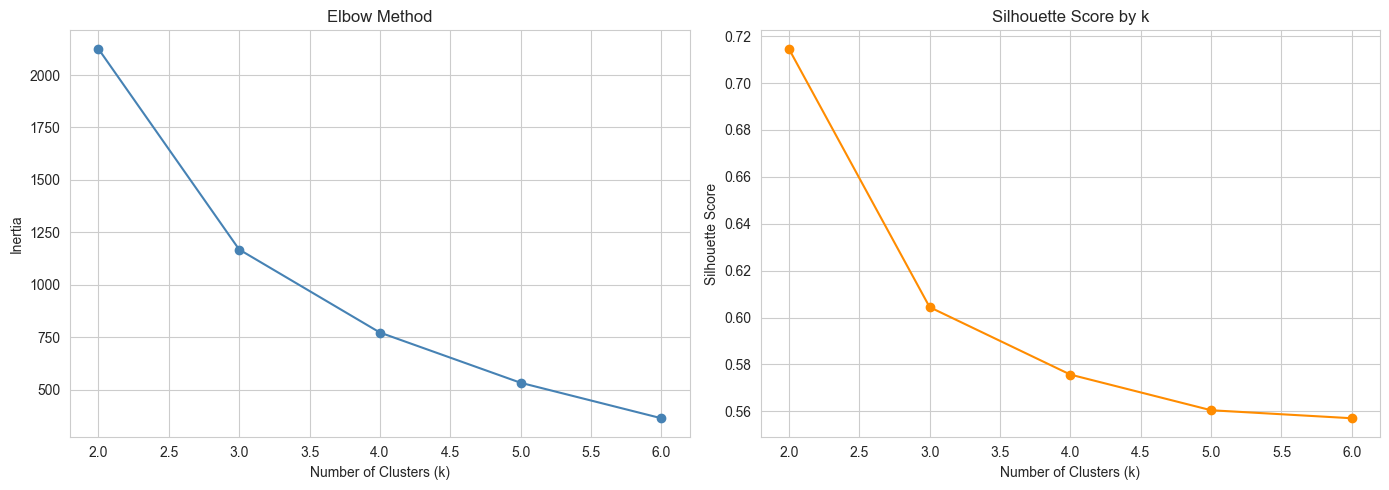

k=2: silhouette score = 0.715
k=3: silhouette score = 0.604
k=4: silhouette score = 0.576
k=5: silhouette score = 0.560
k=6: silhouette score = 0.557


In [16]:
inertias, sil_scores = [], []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_price_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_price_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()
for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette score = {s:.3f}")

In [17]:
#k-means
k_final = 2
kmeans_price = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_clean['cluster_price_only'] = kmeans_price.fit_predict(X_price_scaled)

# Rank clusters by mean price so the labels always make sense (cluster IDs are arbitrary)
cluster_order = df_clean.groupby('cluster_price_only')['price'].mean().sort_values().index
tier_labels = ['Low', 'High']
tier_map = {cluster_id: tier for cluster_id, tier in zip(cluster_order, tier_labels)}
df_clean['price_tier_simple'] = df_clean['cluster_price_only'].map(tier_map)

df_clean.groupby('price_tier_simple')['price'].agg(['count', 'mean', 'min', 'max']).round(0)

,count,mean,min,max
price_tier_simple,,,,
High,434,"1,377,142.00","925,000.00","7,062,500.00"
Low,4115,"462,178.00","7,800.00","921,000.00"


C:\Users\monis\AppData\Local\Temp\ipykernel_25356\2742860562.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='price_tier_simple', y='price',


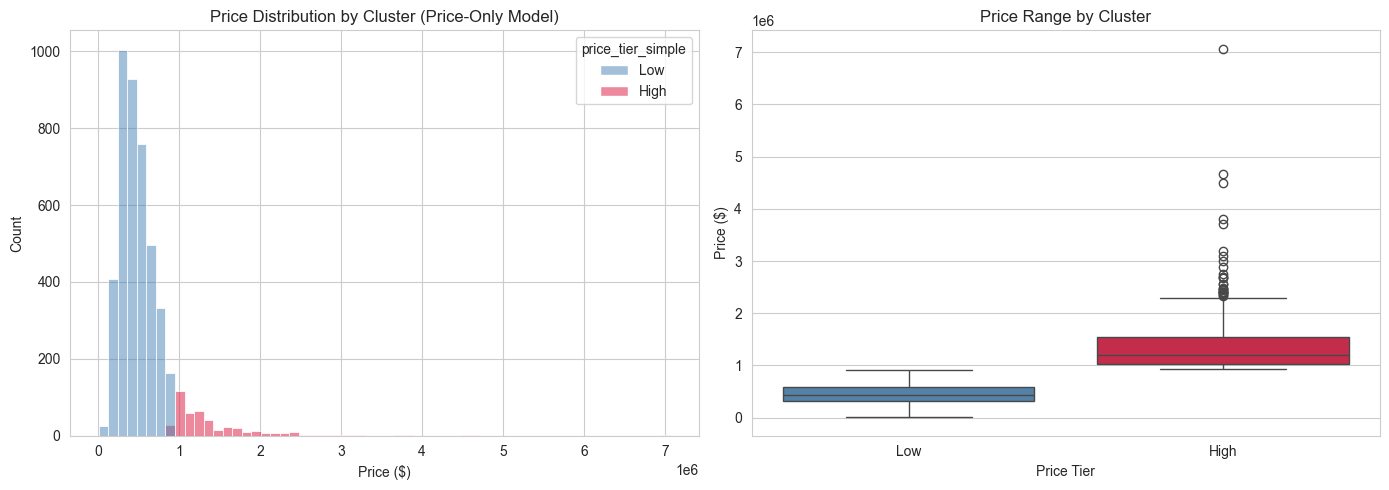

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x='price', hue='price_tier_simple', bins=60,
             palette={'Low': 'steelblue', 'High': 'crimson'}, ax=axes[0])
axes[0].set_title('Price Distribution by Cluster (Price-Only Model)')
axes[0].set_xlabel('Price ($)')

sns.boxplot(data=df_clean, x='price_tier_simple', y='price',
            palette={'Low': 'steelblue', 'High': 'crimson'}, ax=axes[1],
            order=['Low', 'High'])
axes[1].set_title('Price Range by Cluster')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

In [19]:
features_b = ['price', 'sqft_living', 'bedrooms', 'bathrooms']
X_b = df_clean[features_b].values

scaler_b = StandardScaler()
X_b_scaled = scaler_b.fit_transform(X_b)

# Re-check silhouette score for k=2 vs k=3 on this multi-feature space
for k in [2, 3]:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(X_b_scaled)
    print(f"k={k}: silhouette score = {silhouette_score(X_b_scaled, labels_test):.3f}")

k=2: silhouette score = 0.372
k=3: silhouette score = 0.331


In [20]:
kmeans_mf = KMeans(n_clusters=2, random_state=42, n_init=10)
df_clean['cluster_multifeature'] = kmeans_mf.fit_predict(X_b_scaled)

cluster_order_b = df_clean.groupby('cluster_multifeature')['price'].mean().sort_values().index
tier_map_b = {cluster_id: tier for cluster_id, tier in zip(cluster_order_b, ['Low', 'High'])}
df_clean['price_tier_multifeature'] = df_clean['cluster_multifeature'].map(tier_map_b)

df_clean.groupby('price_tier_multifeature')[features_b].mean().round(1)

,price,sqft_living,bedrooms,bathrooms
price_tier_multifeature,,,,
High,"781,334.40","2,979.50",4.10,2.80
Low,"398,346.20","1,580.60",2.90,1.80


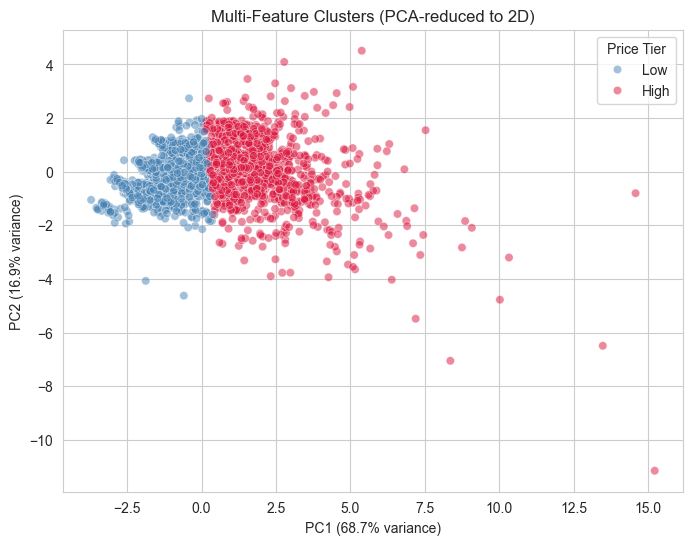

Total variance explained by 2 PCA components: 85.6%


In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_b_scaled)

df_clean['pca1'] = X_pca[:, 0]
df_clean['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='pca1', y='pca2', hue='price_tier_multifeature',
                palette={'Low': 'steelblue', 'High': 'crimson'}, alpha=0.5)
plt.title('Multi-Feature Clusters (PCA-reduced to 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Price Tier')
plt.show()

print(f"Total variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

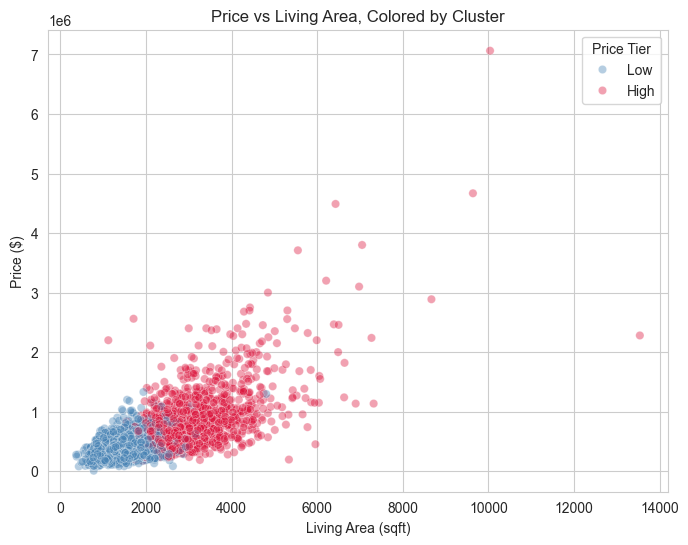

In [22]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='sqft_living', y='price', hue='price_tier_multifeature',
                palette={'Low': 'steelblue', 'High': 'crimson'}, alpha=0.4)
plt.title('Price vs Living Area, Colored by Cluster')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.legend(title='Price Tier')
plt.show()

In [23]:
comparison = pd.crosstab(df_clean['price_tier_simple'], df_clean['price_tier_multifeature'],
                          rownames=['Price-Only Tier'], colnames=['Multi-Feature Tier'])
comparison

Multi-Feature Tier,High,Low
Price-Only Tier,,
High,414,20
Low,1381,2734


In [24]:
agreement = (df_clean['price_tier_simple'] == df_clean['price_tier_multifeature']).mean()
print(f"The two models agree on {agreement*100:.1f}% of houses.")
print("\nDisagreements are typically houses that are expensive for their size/location (or vice versa) —")
print("the multi-feature model picks these up as a different tier than the price-only model would.")

The two models agree on 69.2% of houses.

Disagreements are typically houses that are expensive for their size/location (or vice versa) —
the multi-feature model picks these up as a different tier than the price-only model would.


In [25]:
summary = df_clean.groupby('price_tier_multifeature').agg(
    count=('price', 'count'),
    avg_price=('price', 'mean'),
    avg_sqft_living=('sqft_living', 'mean'),
    avg_bedrooms=('bedrooms', 'mean'),
    avg_bathrooms=('bathrooms', 'mean')
).round(1)
summary

,count,avg_price,avg_sqft_living,avg_bedrooms,avg_bathrooms
price_tier_multifeature,,,,,
High,1795,"781,334.40","2,979.50",4.10,2.80
Low,2754,"398,346.20","1,580.60",2.90,1.80


In [26]:
output_cols = list(df.columns) + ['price_tier_simple', 'price_tier_multifeature']
df_clean[output_cols].to_csv('house_price_clusters_output.csv', index=False)
print("Saved: house_price_clusters_output.csv")
df_clean[output_cols].head()

Saved: house_price_clusters_output.csv


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,price_tier_simple,price_tier_multifeature
0,2014-05-02 00:00:00,"313,000.00",3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,Low,Low
1,2014-05-02 00:00:00,"2,384,000.00",5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,High,High
2,2014-05-02 00:00:00,"342,000.00",3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,Low,Low
3,2014-05-02 00:00:00,"420,000.00",3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,Low,Low
4,2014-05-02 00:00:00,"550,000.00",4.00,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,Low,High
